# EDA

## Daten laden
europe-electricity-load-hourly-20192025 aus Kaggle manuell herunterladen und als csv einlesen

In [1]:
# pip install kagglehub
#import kagglehub
# Download latest version
#file_path = kagglehub.dataset_download("dsersun/europe-electricity-load-hourly-20192025", path="/data/europe-electricity-load-hourly-20192025.csv")

import pandas as pd

# Load the dataset
file_path = "../data/MHLV_2019_2025_combined.csv"
df_energy = pd.read_csv(file_path, parse_dates=['DateUTC', 'DateShort'])

display(df_energy.head())

print(df_energy.info())

print(df_energy.describe())

,MeasureItem,DateUTC,DateShort,TimeFrom,TimeTo,CountryCode,Cov_ratio,Value,Value_ScaleTo100,year
0,Monthly Hourly Load Values,2019-01-01 00:00:00,2019-01-01,1970-01-01 00:00:00,1970-01-01 01:00:00,AT,100,5852.5,5852.5,2019
1,Monthly Hourly Load Values,2019-01-01 01:00:00,2019-01-01,1970-01-01 01:00:00,1970-01-01 02:00:00,AT,100,5619.2,5619.2,2019
2,Monthly Hourly Load Values,2019-01-01 02:00:00,2019-01-01,1970-01-01 02:00:00,1970-01-01 03:00:00,AT,100,5323.9,5323.9,2019
3,Monthly Hourly Load Values,2019-01-01 03:00:00,2019-01-01,1970-01-01 03:00:00,1970-01-01 04:00:00,AT,100,5273.3,5273.3,2019
4,Monthly Hourly Load Values,2019-01-01 04:00:00,2019-01-01,1970-01-01 04:00:00,1970-01-01 05:00:00,AT,100,5439.0,5439.0,2019


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2071728 entries, 0 to 2071727
Data columns (total 10 columns):
 #   Column            Dtype         
---  ------            -----         
 0   MeasureItem       object        
 1   DateUTC           datetime64[ns]
 2   DateShort         datetime64[ns]
 3   TimeFrom          object        
 4   TimeTo            object        
 5   CountryCode       object        
 6   Cov_ratio         int64         
 7   Value             float64       
 8   Value_ScaleTo100  float64       
 9   year              int64         
dtypes: datetime64[ns](2), float64(2), int64(2), object(4)
memory usage: 158.1+ MB
None
                             DateUTC                      DateShort  \
count                        2071728                        2071728   
mean   2022-05-31 21:57:29.807117824  2022-05-31 10:27:35.369430784   
min              2019-01-01 00:00:00            2019-01-01 00:00:00   
25%              2020-09-23 12:00:00            2020-09-23 

In [2]:
print('MeasureItem unique values:')
print(df_energy['MeasureItem'].unique())

print('Cov_ratio unique values:')
print(df_energy['Cov_ratio'].unique())

print('CountryCode value counts:')
print(df_energy['CountryCode'].value_counts())

print('Compare Value and Value_ScaleTo100 columns:')
print(df_energy[df_energy['Value']!=df_energy[ 'Value_ScaleTo100']].head())

MeasureItem unique values:
['Monthly Hourly Load Values']
Cov_ratio unique values:
[100]
CountryCode value counts:
CountryCode
AT    59160
BE    59160
BG    59160
IT    59160
FI    59160
DE    59160
PL    59160
SE    59160
NL    59160
HR    59160
LU    59160
PT    59160
ME    59160
CH    59159
ES    59159
LV    59159
NO    59159
HU    59158
LT    59158
CZ    59154
EE    59153
DK    59152
RS    59152
GR    59152
SK    59137
FR    59094
SI    59078
RO    59077
MK    56184
BA    54532
IE    52989
MD    49417
GB    42011
XK    36038
CY    33513
GE    32220
AL    31440
UA    27203
Name: count, dtype: int64
Compare Value and Value_ScaleTo100 columns:
Empty DataFrame
Columns: [MeasureItem, DateUTC, DateShort, TimeFrom, TimeTo, CountryCode, Cov_ratio, Value, Value_ScaleTo100, year]
Index: []


In [3]:
df_energy = df_energy.drop(columns=['MeasureItem', 'TimeFrom', 'TimeTo', 'Cov_ratio', 'Value_ScaleTo100'], axis=1)
df_energy.head()


,DateUTC,DateShort,CountryCode,Value,year
0,2019-01-01 00:00:00,2019-01-01,AT,5852.5,2019
1,2019-01-01 01:00:00,2019-01-01,AT,5619.2,2019
2,2019-01-01 02:00:00,2019-01-01,AT,5323.9,2019
3,2019-01-01 03:00:00,2019-01-01,AT,5273.3,2019
4,2019-01-01 04:00:00,2019-01-01,AT,5439.0,2019


In [4]:
df_energy.isna().sum()

DateUTC        0
DateShort      0
CountryCode    0
Value          0
year           0
dtype: int64

In [5]:
df_energy['hour'] = df_energy['DateUTC'].dt.hour
df_energy['weekday'] = df_energy['DateUTC'].dt.dayofweek
df_energy['month'] = df_energy['DateUTC'].dt.month
df_energy['is_weekend'] = (df_energy['DateUTC'].dt.weekday >= 5).astype(int)
df_energy.head()

,DateUTC,DateShort,CountryCode,Value,year,hour,weekday,month,is_weekend
0,2019-01-01 00:00:00,2019-01-01,AT,5852.5,2019,0,1,1,0
1,2019-01-01 01:00:00,2019-01-01,AT,5619.2,2019,1,1,1,0
2,2019-01-01 02:00:00,2019-01-01,AT,5323.9,2019,2,1,1,0
3,2019-01-01 03:00:00,2019-01-01,AT,5273.3,2019,3,1,1,0
4,2019-01-01 04:00:00,2019-01-01,AT,5439.0,2019,4,1,1,0


In [11]:
df_energy.to_csv("../data/energy_data.csv", index=False)

In [7]:
df_energy_de = df_energy[df_energy['CountryCode'] == 'DE']
#df_energy_de.head()
df_energy_de = df_energy_de.drop(columns=['CountryCode'], axis=1)
df_energy_de.to_csv("../data/energy_data_de.csv", index=False)

In [2]:
import pandas as pd

df_energy_de = pd.read_csv("../data/energy_data_de.csv", parse_dates=['DateUTC', 'DateShort'])

In [13]:
df_energy_de.describe()

,DateUTC,DateShort,Value,year,hour,weekday,month
count,59160,59160,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000
mean,2022-05-17 11:30:00.365111808,2022-05-17 00:00:00,54663.227387,2021.888032,11.500101,2.999189,6.355375
min,2019-01-01 00:00:00,2019-01-01 00:00:00,30908.880000,2019.000000,0.000000,0.000000,1.000000
25%,2020-09-08 05:45:00,2020-09-08 00:00:00,46803.277500,2020.000000,5.750000,1.000000,3.000000
50%,2022-05-17 11:30:00,2022-05-17 00:00:00,54517.358750,2022.000000,11.500000,3.000000,6.000000
75%,2024-01-23 17:15:00,2024-01-23 00:00:00,62177.330000,2024.000000,17.250000,5.000000,9.000000
max,2025-09-30 23:00:00,2025-09-30 00:00:00,81077.455000,2025.000000,23.000000,6.000000,12.000000
std,NaN,NaN,9666.896304,1.949594,6.922113,2.000017,3.396644


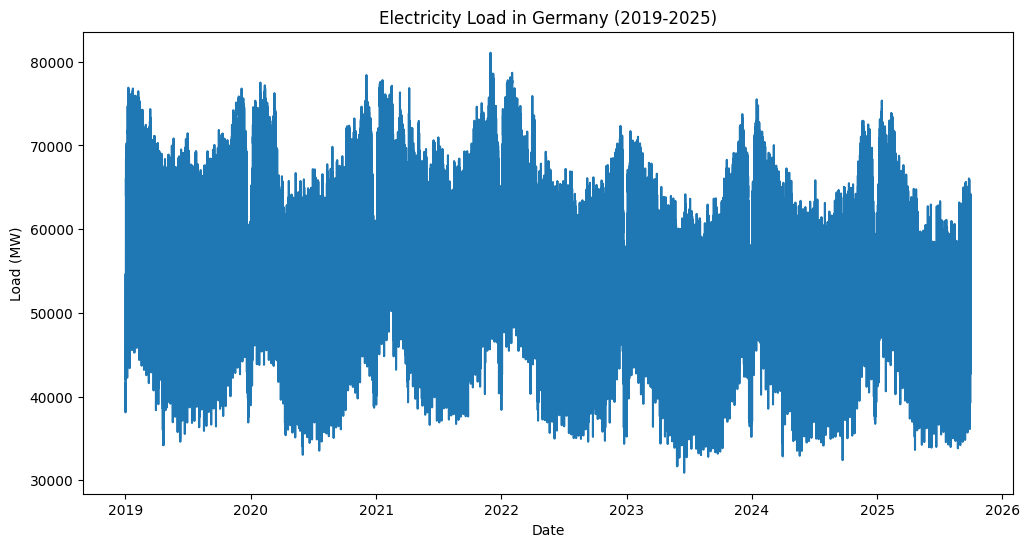

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns   

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_energy_de, x='DateUTC', y='Value')
plt.title('Electricity Load in Germany (2019-2025)')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.show()